In [112]:
import warnings
warnings.filterwarnings("ignore")

import torch
import chemcoord as cc

from ase.io.trajectory import Trajectory
from ase.visualize.plot import plot_atoms

from flonacomldft.utils.silver_isomers_utils import get_construction_table
from flonacomldft.utils.io_utils import load_csv_file, get_path

from flonacomldft.internal_coordinates import Coordinates_mapping

In [113]:
# convention:

#   molecule: ase Atoms object
#   xyz: chemcoord Cartesian object (similar to a dataframe)
#   zmat_matrix: chemcoord Zmat object (similar to a dataframe)
#   zmat: tensor with the internal coordinates

<AxesSubplot:>

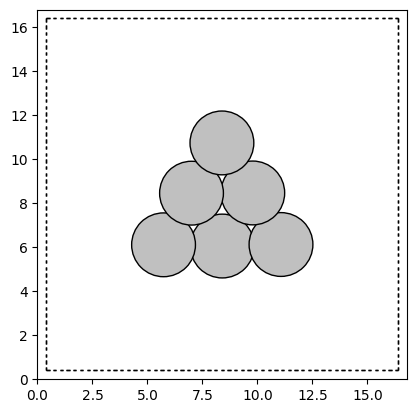

In [114]:
is0_traj = Trajectory(get_path() + 'md_trajectories/ag6_is0_lcao.traj')
coord_mapping = Coordinates_mapping()
ag6  = is0_traj[0] # molecule

plot_atoms(ag6)

In [115]:
xyz = coord_mapping._get_xyz_from_molecule(ag6)
xyz

,atom,x,y,z
0,Ag,8.000809,5.656600,8.0
1,Ag,7.983858,10.343400,8.0
2,Ag,6.601959,8.059975,8.0
3,Ag,5.330772,5.712291,8.0
4,Ag,9.386290,8.069162,8.0
5,Ag,10.669228,5.726007,8.0


In [116]:
zmat_matrix = coord_mapping._get_zmat_matrix_from_xyz(xyz)
zmat_matrix

,atom,b,bond,a,angle,d,dihedral
0,Ag,$\vec{0}$,12.649509,$\vec{e_z}$,50.769952,$\vec{e_x}$,35.260447
2,Ag,0,2.780825,$\vec{e_z}$,94.115069,$\vec{e_x}$,-111.190557
3,Ag,2,2.669744,0,58.634900,$\vec{e_x}$,-41.964342
4,Ag,2,2.784346,3,118.623015,0,-0.000000
5,Ag,4,2.671386,2,118.512795,3,-0.000000
1,Ag,4,2.671886,2,58.528560,3,-180.000000


In [117]:
zmat = coord_mapping._get_zmat_from_zmat_matrix(zmat_matrix)
zmat

tensor([ 2.7808,  2.6697,  2.7843,  2.6714,  2.6719,  1.0234,  2.0704,  2.0684,
         1.0215,  0.0000,  0.0000, -3.1416])

In [118]:
coord_mapping.get_zmat_from_molecule(ag6)

tensor([ 2.7808,  2.6697,  2.7843,  2.6714,  2.6719,  1.0234,  2.0704,  2.0684,
         1.0215,  0.0000,  0.0000, -3.1416])

In [119]:
new_zmat_matrix = coord_mapping._build_zmat_matrix_from_zmat(zmat)
new_zmat_matrix

,atom,b,bond,a,angle,d,dihedral
0,Ag,$\vec{0}$,1.270000,$\vec{e_z}$,127.000106,$\vec{e_x}$,127.000106
2,Ag,0,2.780825,$\vec{e_z}$,127.000106,$\vec{e_x}$,127.000106
3,Ag,2,2.669744,0,58.634900,$\vec{e_x}$,127.000106
4,Ag,2,2.784346,3,118.623010,0,0.000000
5,Ag,4,2.671386,2,118.512798,3,0.000000
1,Ag,4,2.671886,2,58.528560,3,-180.000005


In [120]:
new_xyz = coord_mapping._build_xyz_from_zmat_matrix(new_zmat_matrix)
new_xyz

,atom,x,y,z
0,Ag,-0.610402,0.810027,-0.764307
2,Ag,-1.774534,3.306480,-1.145761
3,Ag,-3.104182,1.320330,0.043685
4,Ag,0.830028,2.837484,-2.011138
5,Ag,1.889366,0.417454,-1.614200
1,Ag,-0.345198,5.213307,-2.347710


<AxesSubplot:>

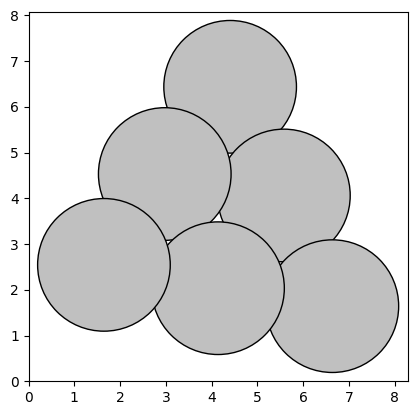

In [121]:
plot_atoms(coord_mapping._build_molecule_from_xyz(new_xyz))

<AxesSubplot:>

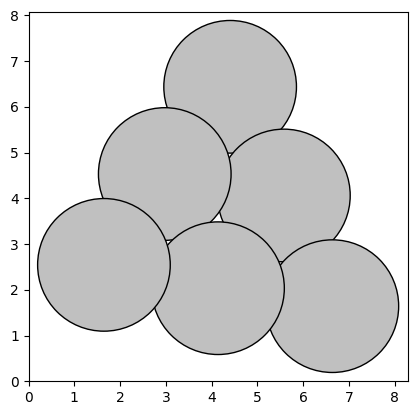

In [122]:
ag6_centered = coord_mapping.build_molecule_from_zmat(zmat)
plot_atoms(ag6_centered)

In [123]:
#cc.Cartesian.from_ase_atoms(ag6_centered)

In [124]:
coord_mapping._orient_and_center_xyz(xyz)

,atom,x,y,z
0,Ag,-0.610402,0.810027,-0.764307
2,Ag,-1.774534,3.306480,-1.145761
3,Ag,-3.104182,1.320330,0.043685
4,Ag,0.830028,2.837484,-2.011138
5,Ag,1.889366,0.417454,-1.614200
1,Ag,-0.345198,5.213307,-2.347710


<AxesSubplot:>

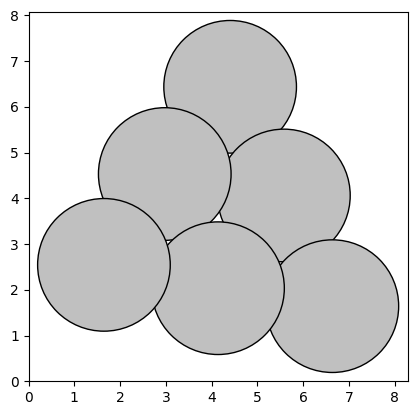

In [125]:
ag6_centered = coord_mapping.reorient_and_center_molecule(ag6)
plot_atoms(ag6_centered)

In [126]:
#cc.Cartesian.from_ase_atoms(ag6_centered)

In [127]:
#coord_mapping.get_internal_from_molecule(ag6_centered)

In [128]:
coord_mapping.logdetjac_zmat_to_xyz(zmat)

(-1.0, 9.439842546803987)

In [129]:
coord_mapping.logdetjac_xyz_to_zmat(xyz)

(-1.0, -9.439842546803986)

In [130]:
coord_mapping.get_internal_from_cartesian(xyz)

(tensor([ 2.7808,  2.6697,  2.7843,  2.6714,  2.6719,  1.0234,  2.0704,  2.0684,
          1.0215,  0.0000,  0.0000, -3.1416]),
 tensor([9.4398]))

In [131]:
coord_mapping.get_internal_from_cartesian(new_xyz)

(tensor([ 2.7808e+00,  2.6697e+00,  2.7843e+00,  2.6714e+00,  2.6719e+00,
          1.0234e+00,  2.0704e+00,  2.0684e+00,  1.0215e+00, -6.2832e+00,
          2.3648e-17,  3.1416e+00]),
 tensor([9.4398]))

In [132]:
coord_mapping.get_cartesian_from_internal(zmat)

(  atom         x         y         z
 0   Ag -0.610402  0.810027 -0.764307
 2   Ag -1.774534  3.306480 -1.145761
 3   Ag -3.104182  1.320330  0.043685
 4   Ag  0.830028  2.837484 -2.011138
 5   Ag  1.889366  0.417454 -1.614200
 1   Ag -0.345198  5.213307 -2.347710,
 tensor([-9.4398]))

In [133]:
coord_mapping.get_internal_from_molecule(ag6)

(tensor([ 2.7808,  2.6697,  2.7843,  2.6714,  2.6719,  1.0234,  2.0704,  2.0684,
          1.0215,  0.0000,  0.0000, -3.1416]),
 tensor([9.4398]))

In [134]:
zmat, logdetjac, energy = coord_mapping.get_internal_from_molecule(ag6, return_potential_energy=True)
zmat, logdetjac, energy

(tensor([ 2.7808,  2.6697,  2.7843,  2.6714,  2.6719,  1.0234,  2.0704,  2.0684,
          1.0215,  0.0000,  0.0000, -3.1416]),
 tensor([9.4398]),
 tensor([-6.8807]))

In [135]:
coord_mapping.get_internal_from_cartesian(new_xyz) 

(tensor([ 2.7808e+00,  2.6697e+00,  2.7843e+00,  2.6714e+00,  2.6719e+00,
          1.0234e+00,  2.0704e+00,  2.0684e+00,  1.0215e+00, -6.2832e+00,
          2.3648e-17,  3.1416e+00]),
 tensor([9.4398]))

In [136]:
zmat = zmat.reshape(1, -1)
xs, logdetjac, energy = coord_mapping.get_real_centered_from_internal(zmat, logdetjac, isomer=0, energies=energy)
xs, logdetjac, energy

(tensor([[ 0.0006, -0.0126, -0.0017, -0.0133, -0.0155, -0.0023, -0.0025, -0.0032,
          -0.0003,  0.0000,  0.0000,  0.0000]]),
 tensor([9.4399]),
 tensor([-6.8807]))

In [137]:
coord_mapping.get_internal_from_real_centered(xs, logdetjac, isomer=0, energies=energy)

(tensor([[ 2.7808,  2.6697,  2.7843,  2.6714,  2.6719,  1.0234,  2.0704,  2.0684,
           1.0215,  0.0000,  0.0000, -3.1416]]),
 tensor([9.4398]),
 tensor([-6.8807]))